# SVM Modell-Training

<img src="Bilder/dslc-model-training.png" width="800" />

## Einlesen der aufbereiteten Daten

Die aufbereiteten Daten enthalten lediglich die Spalte `sentiment`, den Originaltext (für spätere Evaluierungen der Ergebnisse) und Spalten, in denen der Tweet-Text durch unterschiedliche Techniken aufbereitet wurde:

- TODO: Schlussendlich enthaltene Spalten erklären/auflisten

In [1]:
from matplotlib.pyplot import suptitle
from rich import print
from propra_webscience_ws24.constants import (
    PREPARED_TEST_DATASET_FILE_PATH,
    PREPARED_TRAIN_DATASET_FILE_PATH,
    CLASSIFICATION_RESULTS_OUTPUT_FILE_PATH,
)
import pandas as pd

pd.options.display.max_colwidth = None

df_train = pd.read_parquet(PREPARED_TRAIN_DATASET_FILE_PATH)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 8 columns):
 #   Column                           Non-Null Count    Dtype 
---  ------                           --------------    ----- 
 0   sentiment                        1600000 non-null  int64 
 1   text                             1600000 non-null  object
 2   tokenized_text_wo_stop_words     1600000 non-null  object
 3   tokenized_text_w_stop_words      1600000 non-null  object
 4   lemmatized_tokens_wo_stop_words  1600000 non-null  object
 5   lemmatized_tokens_w_stop_words   1600000 non-null  object
 6   stemmed_tokens_wo_stop_words     1600000 non-null  object
 7   stemmed_tokens_w_stop_words      1600000 non-null  object
dtypes: int64(1), object(7)
memory usage: 97.7+ MB


In [2]:
df_test = pd.read_parquet(PREPARED_TEST_DATASET_FILE_PATH)
df_test_wo_neutral = df_test.loc[df_test.sentiment != 2, :]
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   sentiment                        498 non-null    int64 
 1   query                            498 non-null    object
 2   text                             498 non-null    object
 3   tokenized_text_wo_stop_words     498 non-null    object
 4   tokenized_text_w_stop_words      498 non-null    object
 5   lemmatized_tokens_wo_stop_words  498 non-null    object
 6   lemmatized_tokens_w_stop_words   498 non-null    object
 7   stemmed_tokens_wo_stop_words     498 non-null    object
 8   stemmed_tokens_w_stop_words      498 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.1+ KB


## Erzeugen von Modellen und Evaluierung der Ergebnisse

In [3]:
classification_results = []

### Auswahl eines geeigneten Embeddings

Verwendete Ansätze:

* TF-IDF basiertes Embeding 

* Pre-Trained Embedding Wort-Modells (e.g. `word2vec` oder `GLOVE`)

```{note}
Beide Ansätze haben keinerlei kontextuellen Bezug.
```

### TF-IDF Word Embeddings

In [4]:
from propra_webscience_ws24.training import svm

# TODO: remove dataset reduction
df_train = pd.concat(
    [
        df_train.loc[df_train.sentiment == 0, :].head(500_000),
        df_train.loc[df_train.sentiment == 4, :].head(500_000),
    ]
)
tf_idf_results, used_data, trained_model, tfidf_vectorizer = svm.train_with_tf_idf_vectorizer(df_train,
                                                                                              df_test_wo_neutral)
classification_results.extend(tf_idf_results)

max_tokens=None | column='lemmatized_tokens_wo_stop_words' | accuracy_train=0.765 | accuracy_test=0.766
max_tokens=None | column='lemmatized_tokens_w_stop_words' | accuracy_train=0.790 | accuracy_test=0.788
max_tokens=None | column='stemmed_tokens_wo_stop_words' | accuracy_train=0.760 | accuracy_test=0.744
max_tokens=None | column='stemmed_tokens_w_stop_words' | accuracy_train=0.786 | accuracy_test=0.777
max_tokens=1000 | column='lemmatized_tokens_wo_stop_words' | accuracy_train=0.737 | accuracy_test=0.760
max_tokens=1000 | column='lemmatized_tokens_w_stop_words' | accuracy_train=0.766 | accuracy_test=0.769
max_tokens=1000 | column='stemmed_tokens_wo_stop_words' | accuracy_train=0.741 | accuracy_test=0.786
max_tokens=1000 | column='stemmed_tokens_w_stop_words' | accuracy_train=0.770 | accuracy_test=0.786
max_tokens=5000 | column='lemmatized_tokens_wo_stop_words' | accuracy_train=0.764 | accuracy_test=0.799
max_tokens=5000 | column='lemmatized_tokens_w_stop_words' | accuracy_train=0.789

### Bereits existierendes GLOVE Embedding

In [5]:
from propra_webscience_ws24.data import utils as data_utils
from propra_webscience_ws24.constants import (
    GLOVE_EMBEDDING_27B_50D_FILE_PATH,
)

if not GLOVE_EMBEDDING_27B_50D_FILE_PATH.is_file():
    data_utils.download_glove_word_embeddings()

In [6]:
import numpy as np


def create_glove_embedding_structure():
    result = {}

    with open(GLOVE_EMBEDDING_27B_50D_FILE_PATH, "r") as f:
        for l in f:
            values = l.split()
            word = values[0]
            vector = np.array(values[1:], dtype="float32")
            result[word] = vector

    return result


def create_sentence_vector(sentence, embedding):
    words = sentence.split()
    word_vectors = [embedding.get(word) for word in words if word in embedding]
    if word_vectors:
        return np.mean(word_vectors, axis=0)

    return np.zeros(50)  # the vectors have dim 100 due to the chosen embedding size


glove_embedding = create_glove_embedding_structure()

In [7]:
from sklearn.metrics import classification_report
from propra_webscience_ws24.training.svm import ClassificationResult

X_glove_train = (
    df_train[used_data]
    .apply(lambda x: create_sentence_vector(x, glove_embedding))
    .to_list()
)
X_glove_test = (
    df_test_wo_neutral[used_data]
    .apply(lambda x: create_sentence_vector(x, glove_embedding))
    .to_list()
)
result_glove_embedding_train, glove_model = svm.train_linear_svc(
    X_glove_train, df_train.sentiment
)

y_pred_glove = glove_model.predict(X_glove_test)
result_glove_embedding_test = classification_report(
    df_test_wo_neutral.sentiment, y_pred_glove, output_dict=True
)

classifcation_result_glove_embedding = ClassificationResult(
    column_name=used_data,
    embedding='GLOVE',
    report_training_data_test_split=result_glove_embedding_train,
    report_test_data=result_glove_embedding_test,
)
classification_results.append(classifcation_result_glove_embedding)

print(
    f"Train accuracy: {classifcation_result_glove_embedding.train_accuracy} | "
    f"Test accuracy: {classifcation_result_glove_embedding.test_accuracy}"
)

Train accuracy: 0.69673 | Test accuracy: 0.7688022284122563

### Speicherung der Klassifikations-Ergebniss

In [8]:
svm.dump_classification_results(classification_results)

### Vergleich mit BERT-basiertem Modell als Baseline

In [9]:
from transformers import pipeline

sentiment_analysis = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
df_test['baseline_prediction'] = df_test['text'].apply(sentiment_analysis)
df_test

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


,sentiment,query,text,tokenized_text_wo_stop_words,tokenized_text_w_stop_words,lemmatized_tokens_wo_stop_words,lemmatized_tokens_w_stop_words,stemmed_tokens_wo_stop_words,stemmed_tokens_w_stop_words,baseline_prediction
0,4,kindle2,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right.","[loooooooovvvvvveee, kindle2, dx, cool, 2, fantastic, right]","[i, loooooooovvvvvveee, my, kindle2, not, that, the, dx, is, cool, but, the, 2, is, fantastic, in, its, own, right]",loooooooovvvvvveee kindle2 dx cool 2 fantastic right,i loooooooovvvvvveee my kindle2 not that the dx is cool but the 2 is fantastic in it own right,loooooooovvvvvvee kindle2 dx cool 2 fantast right,i loooooooovvvvvvee my kindle2 not that the dx is cool but the 2 is fantast in it own right,"[{'label': 'positive', 'score': 0.9839921593666077}]"
1,4,kindle2,Reading my kindle2... Love it... Lee childs is good read.,"[reading, kindle2, love, lee, childs, good, read]","[reading, my, kindle2, love, it, lee, childs, is, good, read]",reading kindle2 love lee child good read,reading my kindle2 love it lee child is good read,read kindle2 love lee child good read,read my kindle2 love it lee child is good read,"[{'label': 'positive', 'score': 0.9873185753822327}]"
2,4,kindle2,"Ok, first assesment of the #kindle2 ...it fucking rocks!!!","[ok, first, assesment, kindle2, fucking, rocks]","[ok, first, assesment, of, the, kindle2, it, fucking, rocks]",ok first assesment kindle2 fucking rock,ok first assesment of the kindle2 it fucking rock,ok first asses kindle2 fuck rock,ok first asses of the kindle2 it fuck rock,"[{'label': 'positive', 'score': 0.9485466480255127}]"
3,4,kindle2,@kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge! No need for remorse! :),"[love, kindle2, mine, months, never, looked, back, new, big, one, huge, need, remorse]","[you, will, love, your, kindle2, i, have, had, mine, for, a, few, months, and, never, looked, back, the, new, big, one, is, huge, no, need, for, remorse]",love kindle2 mine month never looked back new big one huge need remorse,you will love your kindle2 i have had mine for a few month and never looked back the new big one is huge no need for remorse,love kindle2 mine month never look back new big one huge need remors,you will love your kindle2 i have had mine for a few month and never look back the new big one is huge no need for remors,"[{'label': 'positive', 'score': 0.9834555983543396}]"
4,4,kindle2,@mikefish Fair enough. But i have the Kindle2 and I think it's perfect :),"[fair, enough, kindle2, think, perfect]","[fair, enough, but, i, have, the, kindle2, and, i, think, it, is, perfect]",fair enough kindle2 think perfect,fair enough but i have the kindle2 and i think it is perfect,fair enough kindle2 think perfect,fair enough but i have the kindle2 and i think it is perfect,"[{'label': 'positive', 'score': 0.9709420204162598}]"
...,...,...,...,...,...,...,...,...,...,...
493,2,latex,Ask Programming: LaTeX or InDesign?: submitted by calcio1 [link] [1 comment] http://tinyurl.com/myfmf7,"[ask, programming, latex, indesign, submitted, calcio1, link, 1, comment]","[ask, programming, latex, or, indesign, submitted, by, calcio1, link, 1, comment]",ask programming latex indesign submitted calcio1 link 1 comment,ask programming latex or indesign submitted by calcio1 link 1 comment,ask program latex indesign submit calcio1 link 1 comment,ask program latex or indesign submit by calcio1 link 1 comment,"[{'label': 'neutral', 'score': 0.9134033918380737}]"
494,0,latex,"On that note, I hate Word. I hate Pages. I hate LaTeX. There, I said it. I hate LaTeX. All you TEXN3RDS can come kill me now.","[note, hate, word, hate, pages, hate, latex, said, hate, latex, texn3rds, come, kill]","[on, that, note, i, hate, word, i, hate, pages, i, hate, latex, there, i, said, it, i, hate, latex, all, you, texn3rds, can, come, kill, me, now]",note hate w

In [10]:
def set_sentiment_vals(sentiment) -> int:
    if sentiment == 'positive':
        return 4
    elif sentiment == 'negative':
        return 0
    elif sentiment == 'neutral':
        return 2
    raise ValueError(f"Unknown sentiment {sentiment} found...")


df_test['baseline_sentiment'] = df_test['baseline_prediction'].apply(lambda x: set_sentiment_vals(x[0]['label']))

rows_without_matching_sentiment = df_test.loc[
    df_test.sentiment != df_test.baseline_sentiment, ['text', 'sentiment', 'baseline_sentiment']]
rows_without_matching_sentiment.head(10)

,text,sentiment,baseline_sentiment
12,"House Correspondents dinner was last night whoopi, barbara &amp; sherri went, Obama got a standing ovation",4,2
15,"#lebron best athlete of our generation, if not all time (basketball related) I don't want to get into inter-sport debates about __1/2",4,2
18,"@ludajuice Lebron is a Beast, but I'm still cheering 4 the A..til the end.",0,4
29,"@SoChi2 I current use the Nikon D90 and love it, but not as much as the Canon 40D/50D. I chose the D90 for the video feature. My mistake.",4,2
34,US planning to resume the military tribunals at Guantanamo Bay... only this time those on trial will be AIG execs and Chrysler debt holders,0,2
37,"@sekseemess no. I'm not itchy for now. Maybe later, lol.",0,2
41,is going to sleep then on a bike ride:],4,2
48,?Obama Administration Must Stop Bonuses to AIG Ponzi Schemers ... http://bit.ly/2CUIg,0,2
52,On my way to see Star Trek @ The Esquire.,2,4
53,Going to see star trek soon with my dad.,2,4


In [11]:
print(classification_report(df_test.sentiment, df_test.baseline_sentiment))

precision    recall  f1-score   support

           0       0.94      0.82      0.88       177
           2       0.81      0.87      0.84       139
           4       0.85      0.91      0.88       182

    accuracy                           0.87       498
   macro avg       0.87      0.87      0.87       498
weighted avg       0.87      0.87      0.87       498

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# SVC skaliert sehr schlecht (O(n²) oder O(n³)) => Einschränkung der Daten
df_train_mod = pd.concat(
    [
        df_train.loc[df_train.sentiment == 0, :].head(20000),
        df_train.loc[df_train.sentiment == 4, :].head(20000),
    ]
)
df_train_mod

tfidf_vectorizer = TfidfVectorizer(max_features=None)

X_train = tfidf_vectorizer.fit_transform(df_train_mod.stemmed_tokens_w_stop_words)
y = df_train_mod['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X_train, y, test_size=0.2, random_state=42)

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
print(classification_report(y_test, y_pred_linear))

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
print(classification_report(y_test, y_pred_rbf))

precision    recall  f1-score   support

           0       0.76      0.76      0.76      4014
           4       0.76      0.76      0.76      3986

    accuracy                           0.76      8000
   macro avg       0.76      0.76      0.76      8000
weighted avg       0.76      0.76      0.76      8000

precision    recall  f1-score   support

           0       0.78      0.76      0.77      4014
           4       0.76      0.78      0.77      3986

    accuracy                           0.77      8000
   macro avg       0.77      0.77      0.77      8000
weighted avg       0.77      0.77      0.77      8000

## Visualisierung der Ergebnisse

In [13]:
df_data = [
    {
        "max_tokens": (
            str(result.max_tokens) if result.max_tokens is not None else "All"
        ),
        "used_tokens": result.num_tokens,
        "dataset": result.column_name,
        "test_accuracy": result.test_accuracy,
        "train_accuracy": result.train_accuracy,
    }
    for result in [c for c in classification_results if c.embedding == 'TFIDF']
]

df_results = pd.DataFrame(df_data)
df_results

,max_tokens,used_tokens,dataset,test_accuracy,train_accuracy
0,All,205636,lemmatized_tokens_wo_stop_words,0.766017,0.764575
1,All,205745,lemmatized_tokens_w_stop_words,0.788301,0.789555
2,All,178037,stemmed_tokens_wo_stop_words,0.743733,0.760450
3,All,178073,stemmed_tokens_w_stop_words,0.777159,0.785980
4,1000,1000,lemmatized_tokens_wo_stop_words,0.760446,0.736825
5,1000,1000,lemmatized_tokens_w_stop_words,0.768802,0.766340
6,1000,1000,stemmed_tokens_wo_stop_words,0.785515,0.741360
7,1000,1000,stemmed_tokens_w_stop_words,0.785515,0.770200
8,5000,5000,lemmatized_tokens_wo_stop_words,0.799443,0.763880
9,5000,5000,lemmatized_tokens_w_stop_words,0.796657,0.788525


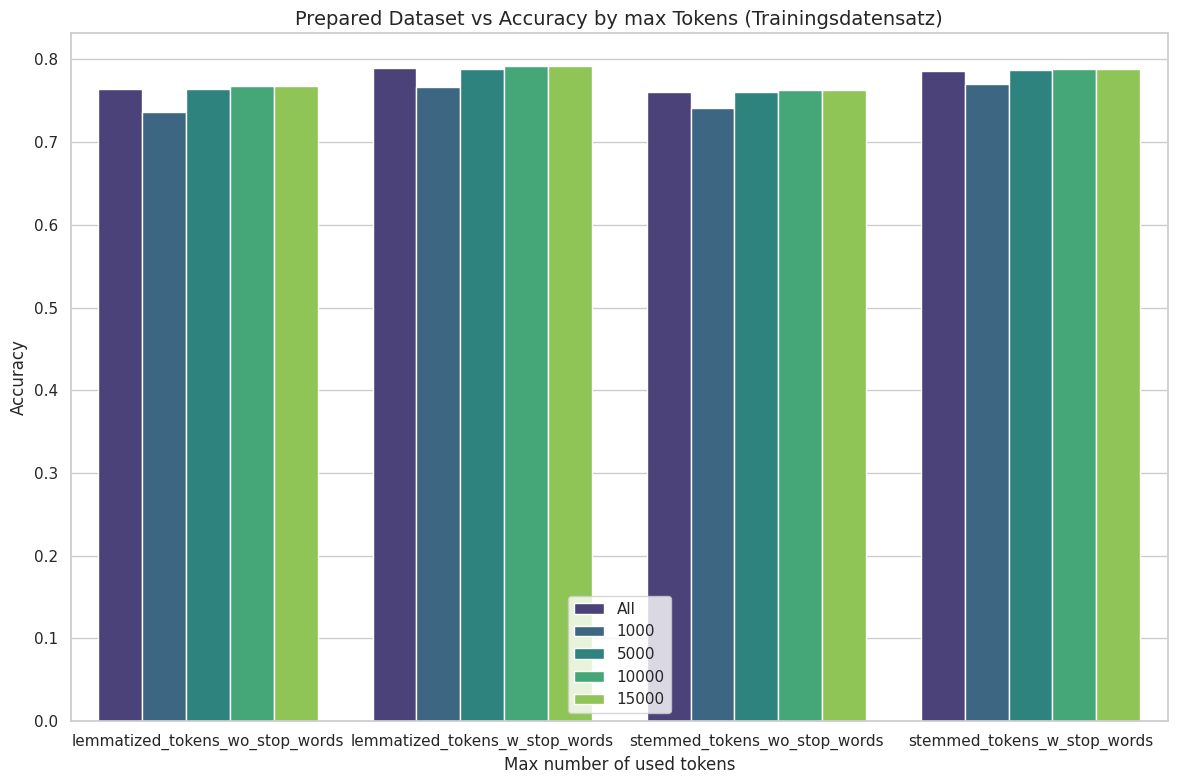

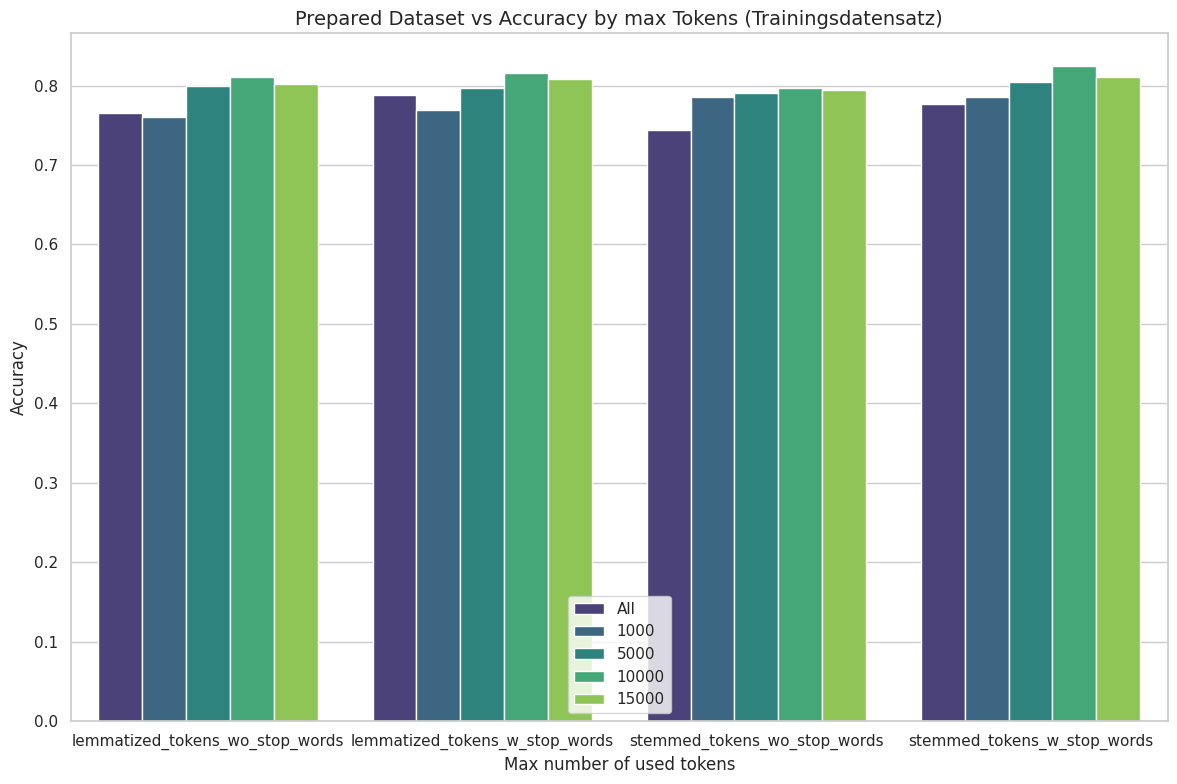

In [14]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

_, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=df_results,
    x="dataset",
    y="train_accuracy",
    hue="max_tokens",
    palette="viridis",
    width=0.8,
    ax=ax,
)

ax.set_title("Prepared Dataset vs Accuracy by max Tokens (Trainingsdatensatz)", fontsize=14)
ax.set_xlabel('Max number of used tokens')
ax.set_ylabel('Accuracy')
plt.legend(loc='lower center')

plt.tight_layout()

_, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=df_results,
    x="dataset",
    y="test_accuracy",
    hue="max_tokens",
    palette="viridis",
    width=0.8,
    ax=ax,
)

ax.set_title("Prepared Dataset vs Accuracy by max Tokens (Trainingsdatensatz)", fontsize=14)
ax.set_xlabel('Max number of used tokens')
ax.set_ylabel('Accuracy')
plt.legend(loc='lower center')

plt.tight_layout()


In [15]:
res = {}
for k,v in tfidf_vectorizer.vocabulary_.items():
    res[k] = int(v)

inverted_res = {}
for v in sorted(res.values()):
    words = []
    for k in res:
        if res[k] == v:
            words.append(k)
    inverted_res[v] = words
inverted_res
    

{0: ['00'],
 1: ['000'],
 2: ['0000'],
 3: ['0007'],
 4: ['000kg'],
 5: ['002'],
 6: ['00am'],
 7: ['00pm'],
 8: ['01'],
 9: ['0116'],
 10: ['01614948343'],
 11: ['018'],
 12: ['02'],
 13: ['026'],
 14: ['02am'],
 15: ['03'],
 16: ['04'],
 17: ['05'],
 18: ['0515'],
 19: ['0517'],
 20: ['05am'],
 21: ['05pm'],
 22: ['06'],
 23: ['06pm'],
 24: ['07'],
 25: ['0730'],
 26: ['0752'],
 27: ['07am'],
 28: ['07raus09'],
 29: ['08'],
 30: ['08am'],
 31: ['09'],
 32: ['09pm'],
 33: ['0b2'],
 34: ['0g'],
 35: ['0h'],
 36: ['0ht'],
 37: ['0mg'],
 38: ['0n'],
 39: ['0r'],
 40: ['10'],
 41: ['100'],
 42: ['1000'],
 43: ['10000'],
 44: ['1000000'],
 45: ['1000fp'],
 46: ['1000th'],
 47: ['1001'],
 48: ['1003'],
 49: ['100gb'],
 50: ['100k'],
 51: ['100m2'],
 52: ['100mb'],
 53: ['100miler'],
 54: ['100plu'],
 55: ['100th'],
 56: ['100to'],
 57: ['100x'],
 58: ['101'],
 59: ['1010'],
 60: ['1012'],
 61: ['101th'],
 62: ['102'],
 63: ['103'],
 64: ['105'],
 65: ['10570'],
 66: ['105f'],
 67: ['106'],


In [16]:
tfidf_vectorizer.transform(['this is a test'])

<1x24465 sparse matrix of type '<class 'numpy.float64'>'
	with 2 stored elements in Compressed Sparse Row format>